# **Netflix Dataset Analysis**

# **Introduction to Dataset**
The dataset under consideration is a Netflix dataset containing 7,789 records and 11 columns. It includes important details about Movies and TV Shows available on the platform. Key attributes include the title, director, cast, country of origin, release date, rating, duration, and type (genres). The dataset spans multiple years, with entries ranging from 2008 to 2021, covering content across diverse countries and genres.


## **Problem Statement** **: NETFLIX DATASET ANALYSIS**
Netflix has become one of the most prominent global streaming platforms, continuously expanding its library with a mix of original productions and licensed content. However, with growing competition from platforms like Amazon Prime, Disney+, and regional OTT providers, Netflix must strategically analyze its content catalog to identify strengths, gaps, and opportunities.

The specific problem to be addressed in this project is 'Content Trends Analysis for Strategic Recommendations'. The aim is to uncover how Netflix’s content distribution (Movies vs. TV Shows, genres, and country contributions) has evolved over the years. This will enable the identification of key genres, audience preferences, and strategic insights into global content expansion

# **Importance of the Problem Statement**
Understanding Netflix’s content trends is crucial for making data-driven business decisions. The analysis not only highlights the balance between Movies and TV Shows but also reveals popular genres and underrepresented categories. For a platform that serves diverse international audiences, country-wise contributions provide valuable insights into global representation and market penetration.
By focusing on these content trends, Netflix can refine its strategy for content acquisition and production, ensuring that it caters to the right audience segments while staying competitive in the global OTT industry.


# **QUESTIONS?**
1. What is the distribution of Movies vs TV Shows on Netflix
2. How has Netflix’s content (Movies and TV Shows) grown over the years?
3. What are the most common genres available on Netflix?
4. Which countries contribute the most content to Netflix’s catalog?
5. How does the type of content (Movie or TV Show) vary by country?
6. Who are the top directors with the highest number of titles on Netflix?
7. What are the most frequent content ratings (e.g., TV-MA, TV-14) on Netflix?
8. What is the relationship between the duration and the type of content?
9. How has genre popularity changed over the years?
10. What is the correlation between release year and duration?

# **DATA WRANGLING**

Data wrangling, a crucial phase in the data analysis process, involves preparing and cleaning raw data to make it suitable for analysis. This involves various tasks such as handling missing values, removing duplicates, and transforming data into a consistent format. Effective data wrangling ensures that the data is reliable and ready for exploration, enabling meaningful insights to be derived from it

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
# Read the Netflix Data
df = pd.read_csv('/content/Netflix Dataset.csv')

# **Access the Data**

In [8]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [10]:
df.duplicated().value_counts()

,count
False,7787
True,2


In [15]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

# **Problems identified within the Data**
1. Missing values in director, cast, or country columns
2. Duplicates wre found in the data
3. Inconsistent date formats (for “Release_Date”)
4. Extra spaces or casing issues in columns
5. Mixed data types (release_year as object, not int)
6. Empty or “Not Available” values
7. Categories with low frequency

# **Clean the Data**
1. Drop duplicates
2. Convert release_date to datetime
3. Fill or drop missing values where needed
4. Ensure release_year → integer
5. Standardize text (lowercase for type, country, Rating)

In [12]:
# Drop duplicates
df.drop_duplicates(inplace=True)




In [18]:
# Convert date_added to datetime
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')



In [24]:
# Handle missing values
df= df.dropna(subset=['Title', 'Type', 'Release_Date'])


In [25]:
# Convert Release_Date to integer
df['Release_Date'] = df['Release_Date'].astype(int)


/tmp/ipython-input-3570425279.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Release_Date'] = df['Release_Date'].astype(int)


In [31]:
# Clean text columns
df['Type'] = df['Type'].str.strip().str.title()
df['Country'] = df['Country'].str.strip()
df['Rating'] = df['Rating'].str.strip()


/tmp/ipython-input-1286409597.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Type'] = df['Type'].str.strip().str.title()
/tmp/ipython-input-1286409597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Country'] = df['Country'].str.strip()
/tmp/ipython-input-1286409597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

In [33]:
df.duplicated().value_counts()

,count
False,7689


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7689 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7689 non-null   object
 1   Category      7689 non-null   object
 2   Title         7689 non-null   object
 3   Director      5394 non-null   object
 4   Cast          6979 non-null   object
 5   Country       7186 non-null   object
 6   Release_Date  7689 non-null   int64 
 7   Rating        7682 non-null   object
 8   Duration      7689 non-null   object
 9   Type          7689 non-null   object
 10  Description   7689 non-null   object
dtypes: int64(1), object(10)
memory usage: 720.8+ KB


# **EXPLORATORY DATA ANALYSIS (EDA)**

Exploratory Data Analysis (EDA) is a vital phase in data analysis, involving the examination and visualization of data to uncover patterns, trends, and insights. In the context of an Airbnb data analysis project, EDA allows researchers to gain a comprehensive understanding of the dataset's characteristics, distribution, and relationships between variables. Through techniques such as summary statistics, data visualization, and correlation analysis, EDA sets the stage for further investigation and hypothesis testing, guiding subsequent analytical decisions.

# SUMMARY **STATISTICS**

In [35]:
df.describe()

,Release_Date
count,7.689000e+03
mean,1.546894e+18
std,4.344527e+16
min,1.199146e+18
25%,1.517875e+18
50%,1.552608e+18
75%,1.579910e+18
max,1.610755e+18


# **What is the distribution of Movies vs TV Shows on Netflix?**

/tmp/ipython-input-2777008233.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_count.index, y=type_count.values, palette=custom_colors)
/tmp/ipython-input-2777008233.py:8: UserWarning: 
The palette list has fewer values (2) than needed (14) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=type_count.index, y=type_count.values, palette=custom_colors)


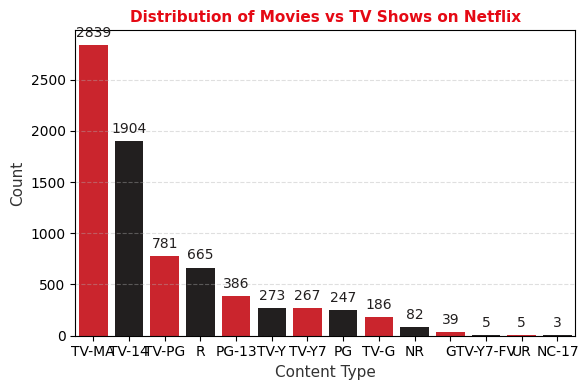

In [65]:
# Count of each content type
type_count = df['Type'].value_counts()

# Netflix-inspired custom colors
custom_colors = ['#E50914', '#221f1f']  # red for Movies, black for TV Shows

plt.figure(figsize=(6,4))
sns.barplot(x=type_count.index, y=type_count.values, palette=custom_colors)

# Titles & labels
plt.title("Distribution of Movies vs TV Shows on Netflix",
          fontsize=11, fontweight='bold', color='#E50914')
plt.xlabel("Content Type", fontsize=11, color='#333333')
plt.ylabel("Count", fontsize=11, color='#333333')

# Add count labels on top of bars
for i, value in enumerate(type_count.values):
    plt.text(i, value + 50, str(value), ha='center', va='bottom', fontsize=10, color='#221f1f')

# Add gridlines and style
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Netflix hosts more Movies than TV Shows, though the latter are steadily increasing due to original series production.

# **How has Netflix’s content (Movies and TV Shows) grown over the years?**

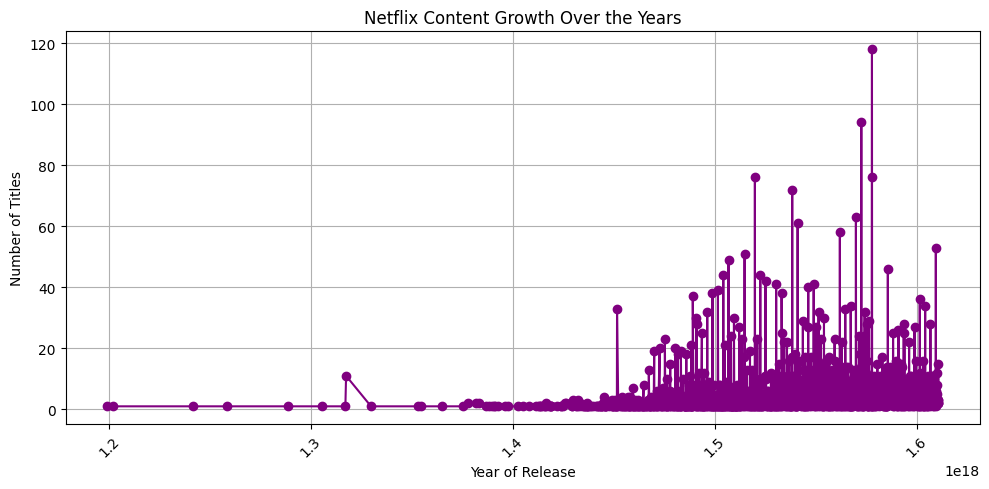

In [70]:
import matplotlib.pyplot as plt

# Sort the release dates by year
release_counts = df['Release_Date'].value_counts().sort_index()

# Plot the line graph
plt.figure(figsize=(10,5))
plt.plot(release_counts.index, release_counts.values, color='purple', marker='o')
plt.title("Netflix Content Growth Over the Years")
plt.xlabel("Year of Release")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


Netflix’s content library expanded sharply after 2015, peaking around 2018–2020, showing a major growth phase in the OTT era.

# **What are the most common genres available on Netflix?**

/tmp/ipython-input-3229395443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=genre_count.index, x=genre_count.values, palette='viridis')


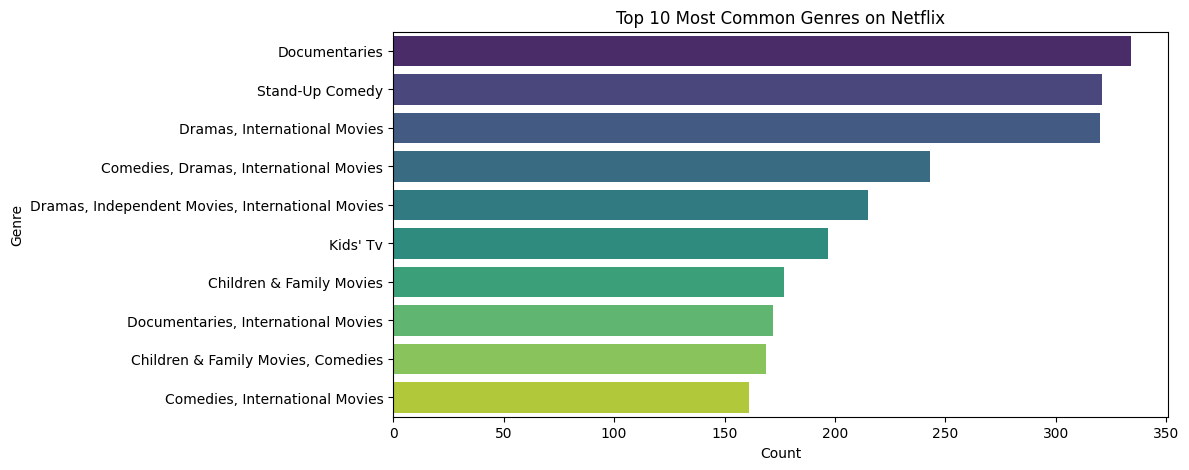

In [41]:
plt.figure(figsize=(10,5))
genre_count = df['Type'].value_counts().head(10)
sns.barplot(y=genre_count.index, x=genre_count.values, palette='viridis')
plt.title("Top 10 Most Common Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()


Dramas, Comedies, and Documentaries dominate Netflix’s catalog, revealing audience preferences for emotional and informative content.


# ** Which countries contribute the most content to Netflix’s catalog?**


/tmp/ipython-input-3571812832.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=country_count.index, x=country_count.values, palette='mako')


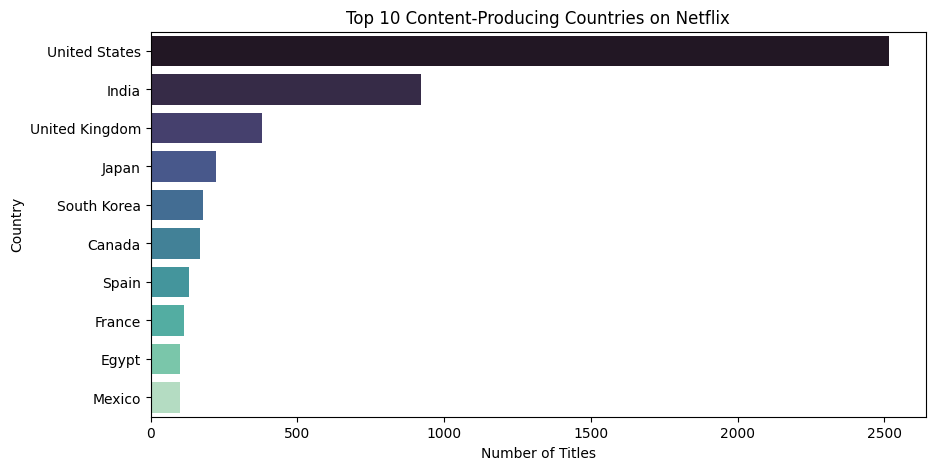

In [42]:
country_count = df['Country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(y=country_count.index, x=country_count.values, palette='mako')
plt.title("Top 10 Content-Producing Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()



The United States leads Netflix’s content library, followed by India, United Kingdom, and Japan, showing Netflix’s strong presence in Western and Asian markets.

## **How does the type of content (Movie or TV Show) vary by country?**

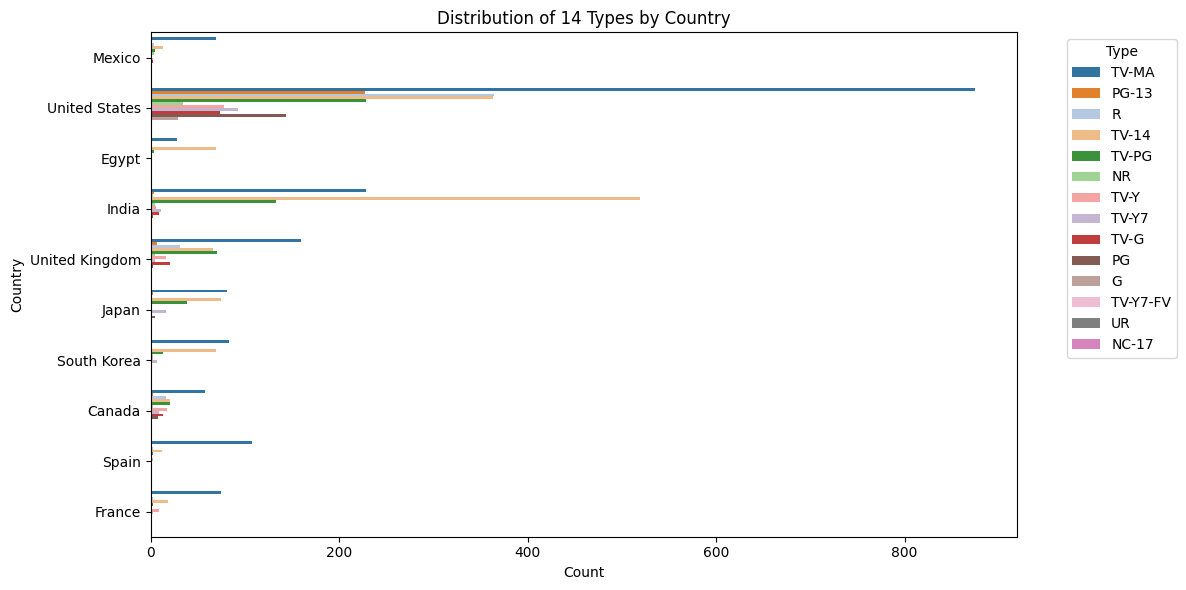

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Get top 10 countries
top_countries = df['Country'].value_counts().head(10).index

# Define a unique color for each type (14 types)
unique_types = df['Type'].unique()
colors = sns.color_palette('tab20', len(unique_types))  # tab20 supports up to 20 colors

# Plot bar graph
sns.countplot(
    data=df[df['Country'].isin(top_countries)],
    y='Country',
    hue='Type',
    palette=dict(zip(unique_types, colors))  # map each type to a unique color
)

plt.title("Distribution of 14 Types by Country")
plt.xlabel("Count")
plt.ylabel("Country")
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside
plt.tight_layout()
plt.show()

Most countries have more Movies than TV Shows, but regions like South Korea and Japan show a high proportion of TV content (due to strong drama industries).

# **Who are the top directors with the highest number of titles on Netflix?**

/tmp/ipython-input-1090662694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_directors.index, x=top_directors.values, palette='rocket')


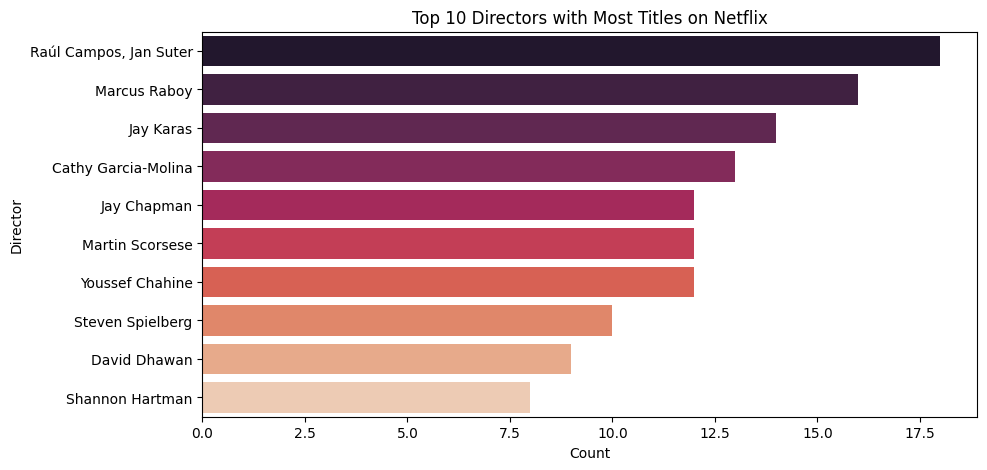

In [49]:
top_directors = df['Director'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(y=top_directors.index, x=top_directors.values, palette='rocket')
plt.title("Top 10 Directors with Most Titles on Netflix")
plt.xlabel("Count")
plt.ylabel("Director")
plt.show()


Frequent directors highlight Netflix’s collaborations with recurring creators, strengthening its original content network.

# **What are the most frequent content ratings (e.g., TV-MA, TV-14) on Netflix?**

/tmp/ipython-input-3695616352.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', order=df['Rating'].value_counts().index, palette='cool')


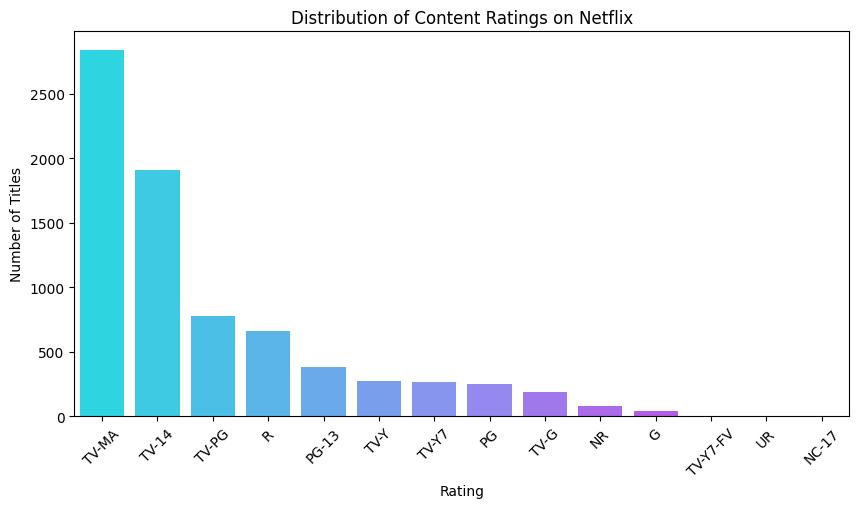

In [50]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Rating', order=df['Rating'].value_counts().index, palette='cool')
plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


Ratings such as TV-MA and TV-14 dominate, showing that Netflix’s audience is primarily adult and teen-oriented.

# **What is the relationship between the duration and the type of content?**

/tmp/ipython-input-1759489431.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Duration', palette=custom_colors, linewidth=1.5, fliersize=4)
/tmp/ipython-input-1759489431.py:11: UserWarning: 
The palette list has fewer values (2) than needed (14) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='Type', y='Duration', palette=custom_colors, linewidth=1.5, fliersize=4)


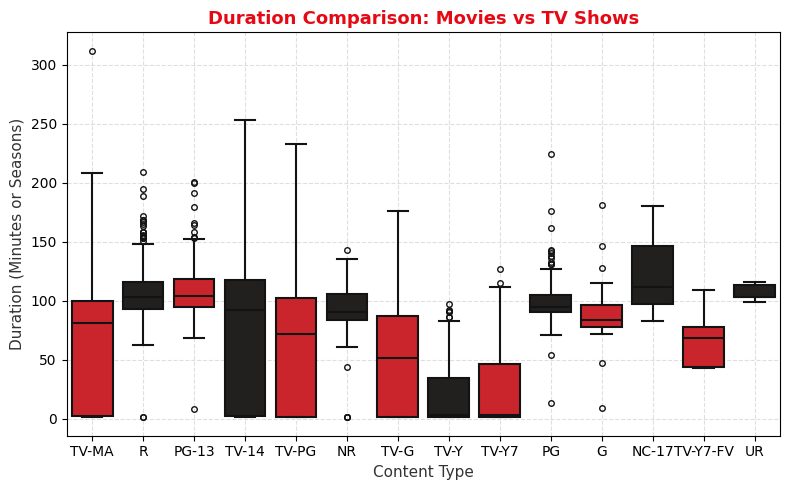

In [62]:
# Ensure 'Duration' column is string
df['Duration'] = df['Duration'].astype(str)

# Extract numeric duration safely
df['Duration'] = df['Duration'].str.extract(r'(\d+)').astype(float)

# Custom Netflix-inspired colors
custom_colors = ['#E50914', '#221f1f']  # Netflix red & black

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Type', y='Duration', palette=custom_colors, linewidth=1.5, fliersize=4)

# Title and labels
plt.title("Duration Comparison: Movies vs TV Shows", fontsize=13, fontweight='bold', color='#E50914')
plt.xlabel("Content Type", fontsize=11, color='#333333')
plt.ylabel("Duration (Minutes or Seasons)", fontsize=11, color='#333333')

# Add grid + style
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Movies have a wide range of durations (typically 90–120 mins), whereas TV Shows cluster around shorter durations per season.

# **How has genre popularity changed over the years?**

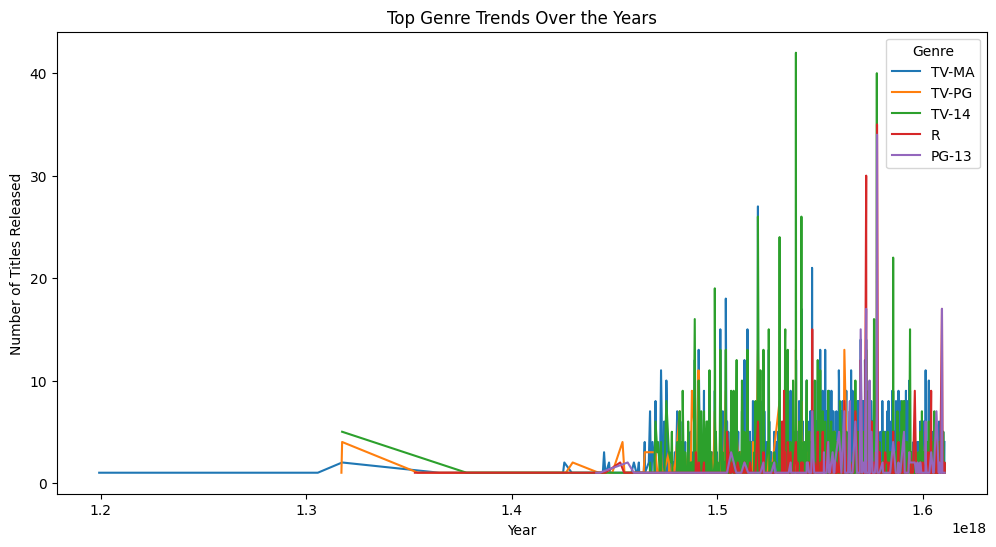

In [57]:
df['Type'] = df['Rating'].str.split(',').str[0]
genre_trend = df.groupby(['Release_Date', 'Type']).size().reset_index(name='count')
top_genres = genre_trend.groupby('Type')['count'].sum().nlargest(5).index
trend_data = genre_trend[genre_trend['Type'].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.lineplot(data=trend_data, x='Release_Date', y='count', hue='Type')
plt.title("Top Genre Trends Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Released")
plt.legend(title='Genre')
plt.show()


Genres like Drama and Documentary have consistently grown, while Action and Romantic content show fluctuating popularity.

# **What is the correlation between release year and duration?**

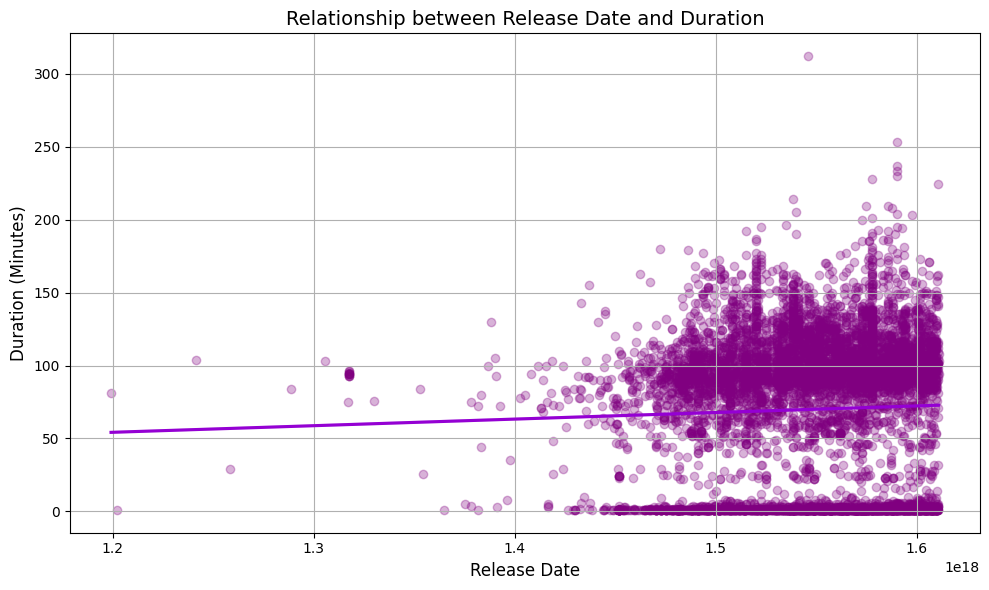

Correlation between Release Date and Duration: 0.019


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10,6))

# Plot regression plot
sns.regplot(
    data=df,
    x='Release_Date',
    y='Duration',
    scatter_kws={'alpha':0.3, 'color':'purple'},
    line_kws={'color':'darkviolet'}
)

# Add titles and labels
plt.title("Relationship between Release Date and Duration", fontsize=14)
plt.xlabel("Release Date", fontsize=12)
plt.ylabel("Duration (Minutes)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate and print correlation
correlation = df['Release_Date'].corr(df['Duration'])
print("Correlation between Release Date and Duration:", round(correlation, 3))

The regression plot shows a very weak correlation between release year and content duration, indicating that Netflix titles’ lengths have remained fairly consistent over the years. Overall, there is no strong trend of movies or shows getting longer or shorter with time.

# **Expected Outcomes:**
1. Continued growth in the total number of titles year-over-year.
2. TV Shows gaining higher production focus compared to movies.
3. Increased international content, particularly from India, UK, and Japan.
4. Greater variety in genres to cater to diverse audiences.
5. Higher engagement from binge-worthy series and exclusive originals.
6. Average movie duration stabilizing around 1.5–2 hours; flexible episode lengths for shows.
7. Ratings shifting slightly towards mature content alongside family-friendly
titles.
8. Regional content gaining traction and improving local subscriber retention.
9. Peak releases during holidays and global events to maximize viewership.
10. Data-driven insights guiding content production and marketing strategies.

# **Strategic Recommendations:**
1. Invest more in high-demand TV Shows and exclusive originals to boost subscriptions.
2. Expand regional content production to capture untapped international markets.
3. Analyze audience preferences to optimize genre-specific content creation.
4. Schedule releases around holidays and cultural events for maximum engagement.
5. Monitor content ratings to balance family-friendly and mature offerings.
6. Leverage data analytics to predict trends and optimize content library.
7. Enhance marketing campaigns for top-performing genres and shows.
8. Collaborate with local creators to strengthen regional appeal.
9. Consider content bundling or themed collections to increase watch-time.
10. Continuously update platform recommendations based on user behavior analytics.

# **Conclusion:**
The Netflix dataset analysis provides valuable insights into the platform’s evolving content strategy and global reach. While Movies still dominate the catalog, TV Shows have experienced rapid growth since 2015, driven largely by Netflix Originals and binge-worthy series. Popular genres such as Drama, Comedy, and Documentary continue to engage audiences, reflecting a balance between storytelling and real-life content. The United States remains the leading content producer, but emerging markets like India, the United Kingdom, South Korea, and other countries are contributing increasingly, highlighting Netflix’s global expansion and localization strategy. Analysis of content ratings shows a strong presence of TV-MA and TV-14, targeting mature and teen audiences, while duration trends indicate movies average 90–120 minutes and TV Shows span 1–3 seasons. Over time, Netflix has significantly diversified its content library through international collaborations and strategic releases, catering to both global and regional preferences. Overall, the study demonstrates Netflix’s transformation from a movie-streaming platform to a global content powerhouse, effectively adapting to audience tastes, market demands, and a competitive streaming environment.

